In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

In [2]:
condkyoto = pd.read_csv('HEIGHT      S0            S1_lat-60_lon120.txt',index_col="HEIGHT",sep="   ")

C:\Users\tedea\AppData\Local\Temp\ipykernel_14540\1730664181.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  condkyoto = pd.read_csv('HEIGHT      S0            S1_lat-60_lon120.txt',index_col="HEIGHT",sep="   ")


In [3]:
condkyoto

,S0,S1,S2
HEIGHT,,,
100.0,0.049388,9.646000e-06,1.826390e-04
110.0,0.241308,6.347590e-05,2.290960e-04
120.0,0.592739,1.176880e-04,1.102640e-04
130.0,1.247610,8.236170e-05,2.889520e-05
140.0,2.337430,5.177650e-05,8.657480e-06
150.0,3.847690,3.393770e-05,3.109770e-06
160.0,5.753010,2.320330e-05,1.276810e-06
170.0,7.988640,1.626250e-05,5.740880e-07
180.0,10.497300,1.159810e-05,2.764800e-07


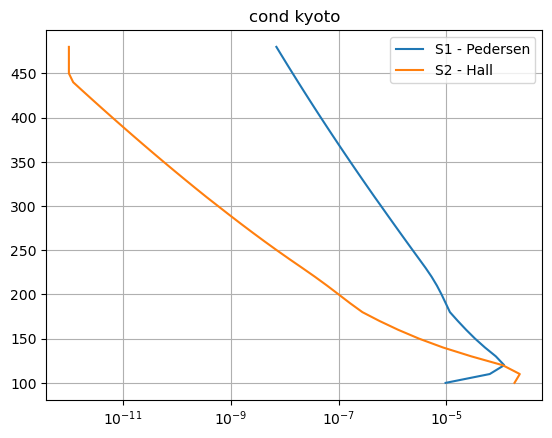

In [4]:
#plt.semilogx(condkyoto['S0'],condkyoto.index.get_level_values('HEIGHT').unique(),label="S0 - Paralela")
plt.semilogx(condkyoto["S1"],condkyoto.index.get_level_values('HEIGHT').unique(),label="S1 - Pedersen")
plt.plot(condkyoto["S2"],condkyoto.index.get_level_values('HEIGHT').unique(),label="S2 - Hall")

plt.legend()
plt.title("cond kyoto")
plt.grid()

In [5]:
hall = pd.read_csv("Condutividade_de_Hall.csv")
hall

,ht,lat,lon,time,0
0,100.0,-80.0,0.0,0 days 00:00:00,0.000119
1,100.0,-80.0,0.0,0 days 00:15:00,0.000119
2,100.0,-80.0,0.0,0 days 00:30:00,0.000119
3,100.0,-80.0,0.0,0 days 00:45:00,0.000119
4,100.0,-80.0,0.0,0 days 01:00:00,0.000120
...,...,...,...,...,...
587515,480.0,80.0,340.0,0 days 22:45:00,0.000265
587516,480.0,80.0,340.0,0 days 23:00:00,0.000268
587517,480.0,80.0,340.0,0 days 23:15:00,0.000270
587518,480.0,80.0,340.0,0 days 23:30:00,0.000273


In [6]:
pedersen = pd.read_csv("Condutividade_de_Pedersen.csv")
pedersen

,ht,lat,lon,time,0
0,100.0,-80.0,0.0,0 days 00:00:00,1.227699e-07
1,100.0,-80.0,0.0,0 days 00:15:00,1.229439e-07
2,100.0,-80.0,0.0,0 days 00:30:00,1.232755e-07
3,100.0,-80.0,0.0,0 days 00:45:00,1.237615e-07
4,100.0,-80.0,0.0,0 days 01:00:00,1.243970e-07
...,...,...,...,...,...
587515,480.0,80.0,340.0,0 days 22:45:00,4.459838e-15
587516,480.0,80.0,340.0,0 days 23:00:00,4.535907e-15
587517,480.0,80.0,340.0,0 days 23:15:00,4.615148e-15
587518,480.0,80.0,340.0,0 days 23:30:00,4.695789e-15


In [7]:
def to_multiindex_conductivities(df):
    df.sort_values(['time','ht','lat','lon'],inplace = True)
    return df.set_index(['time','ht','lat','lon'])

In [8]:
hall = to_multiindex_conductivities(hall)
pedersen = to_multiindex_conductivities(pedersen)

In [9]:
plotpedersen = pedersen.loc["0 days 00:00:00",:,-60,300]
plothall = hall.loc["0 days 00:00:00",:,-60,300]

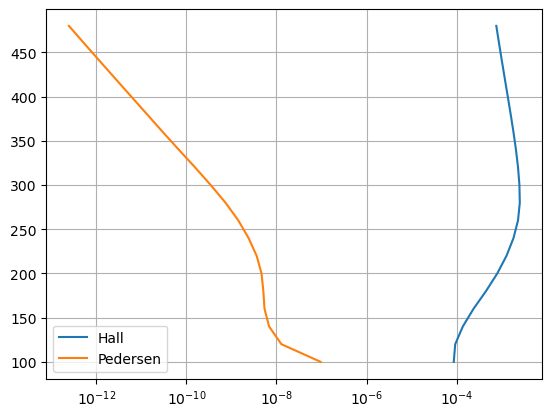

In [10]:
plt.plot(plothall,hall.index.get_level_values('ht').unique(),label="Hall")
plt.semilogx(plotpedersen,pedersen.index.get_level_values('ht').unique(),label= "Pedersen")

plt.legend()
plt.grid()

In [11]:
height = hall.index.get_level_values('ht').unique().to_list()
condkyoto2 = condkyoto.loc[height]

In [12]:
condkyoto2

,S0,S1,S2
HEIGHT,,,
100.0,0.049388,9.646000e-06,1.826390e-04
120.0,0.592739,1.176880e-04,1.102640e-04
140.0,2.337430,5.177650e-05,8.657480e-06
160.0,5.753010,2.320330e-05,1.276810e-06
180.0,10.497300,1.159810e-05,2.764800e-07
200.0,18.086700,8.114360e-06,1.004280e-07
220.0,25.556100,5.308940e-06,3.644350e-08
240.0,31.194000,3.120230e-06,1.224770e-08
260.0,36.055400,1.803240e-06,4.241200e-09


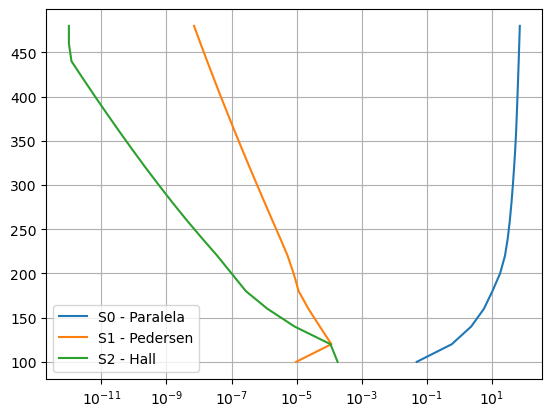

In [13]:
plt.semilogx(condkyoto2['S0'],condkyoto2.index.get_level_values('HEIGHT').unique(),label="S0 - Paralela")
plt.plot(condkyoto2["S1"],condkyoto2.index.get_level_values('HEIGHT').unique(),label="S1 - Pedersen")
plt.plot(condkyoto2["S2"],condkyoto2.index.get_level_values('HEIGHT').unique(),label="S2 - Hall")
plt.legend()
plt.grid()

In [14]:
diff_pedersen = condkyoto2["S1"] - plotpedersen["0"]
diff_hall = condkyoto2["S1"] - plothall["0"]

In [15]:
diff_hall.to_csv("diff_hall.csv")
diff_hall.index,condkyoto2["S2"]

(Index([100.0, 120.0, 140.0, 160.0, 180.0, 200.0, 220.0, 240.0, 260.0, 280.0,
        300.0, 320.0, 340.0, 360.0, 380.0, 400.0, 420.0, 440.0, 460.0, 480.0],
       dtype='float64', name='HEIGHT'),
 HEIGHT
 100.0    1.826390e-04
 120.0    1.102640e-04
 140.0    8.657480e-06
 160.0    1.276810e-06
 180.0    2.764800e-07
 200.0    1.004280e-07
 220.0    3.644350e-08
 240.0    1.224770e-08
 260.0    4.241200e-09
 280.0    1.541060e-09
 300.0    5.813820e-10
 320.0    2.244720e-10
 340.0    8.956950e-11
 360.0    3.650890e-11
 380.0    1.517100e-11
 400.0    6.415120e-12
 420.0    2.756110e-12
 440.0    1.201740e-12
 460.0    1.000000e-12
 480.0    1.000000e-12
 Name: S2, dtype: float64)

In [16]:
pedersen

0
time            ht    lat   lon                
0 days 00:00:00 100.0 -80.0 0.0    1.227699e-07
                            20.0   1.295188e-07
                            40.0   1.432761e-07
                            60.0   1.633973e-07
                            80.0   1.890447e-07
...                                         ...
0 days 23:45:00 480.0  80.0 260.0  9.783716e-15
                            280.0  8.648465e-15
                            300.0  5.211839e-15
                            320.0  4.924690e-15
                            340.0  4.776177e-15

[587520 rows x 1 columns]

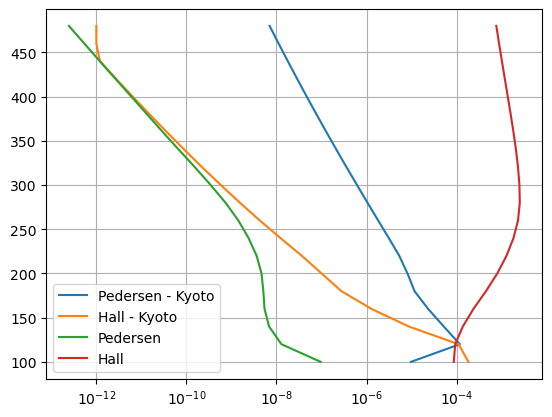

In [17]:
#plt.semilogx(diff_hall,diff_hall.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Hall")
#plt.plot(diff_pedersen,diff_pedersen.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Pedersen")
h=4300
plt.plot(condkyoto2["S1"].loc[:h],condkyoto2.loc[:h].index.get_level_values('HEIGHT').unique(),label="Pedersen - Kyoto")
plt.plot(condkyoto2["S2"].loc[:h],condkyoto2.loc[:h].index.get_level_values('HEIGHT').unique(),label="Hall - Kyoto")

plt.semilogx(plotpedersen.loc[:h],pedersen.loc["0 days 00:00:00",:h,:,:].index.get_level_values('ht').unique(),label= "Pedersen")
plt.plot(plothall.loc[:h],hall.loc["0 days 00:00:00",:h,:,:].index.get_level_values('ht').unique(),label="Hall")

plt.legend()
plt.grid()
plt.savefig("kyoto_CondutividadePedersen_lat-60_lon120_s20_01JAN2008_2.tiff",dpi=1000)

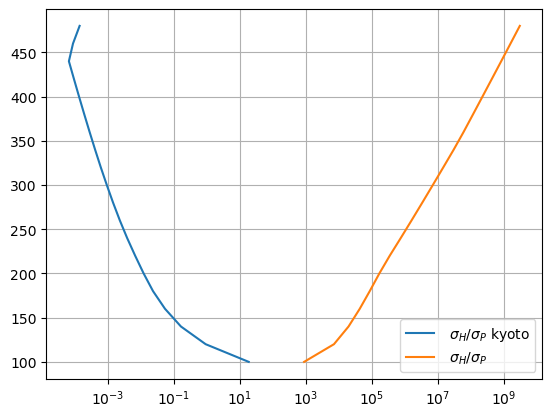

In [18]:
#plt.semilogx(diff_hall,diff_hall.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Hall")
#plt.plot(diff_pedersen,diff_pedersen.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Pedersen")
ht=condkyoto2.index.get_level_values('HEIGHT').unique()
plt.plot((condkyoto2["S2"]/condkyoto2["S1"]).loc[:h],condkyoto2.loc[:h].index.get_level_values('HEIGHT').unique(),label=" $\sigma_H$/$\sigma_P$ kyoto")

plt.semilogx((plothall/plotpedersen).loc[:h],pedersen.loc["0 days 00:00:00",:h,:,:].index.get_level_values('ht').unique(),label= " $\sigma_H$/$\sigma_P$")

plt.legend()
plt.grid()
plt.savefig("kyotoCondutividadePedersen_divided_lat-60_lon120_s20_01JAN2008_2.tiff",dpi=1000)

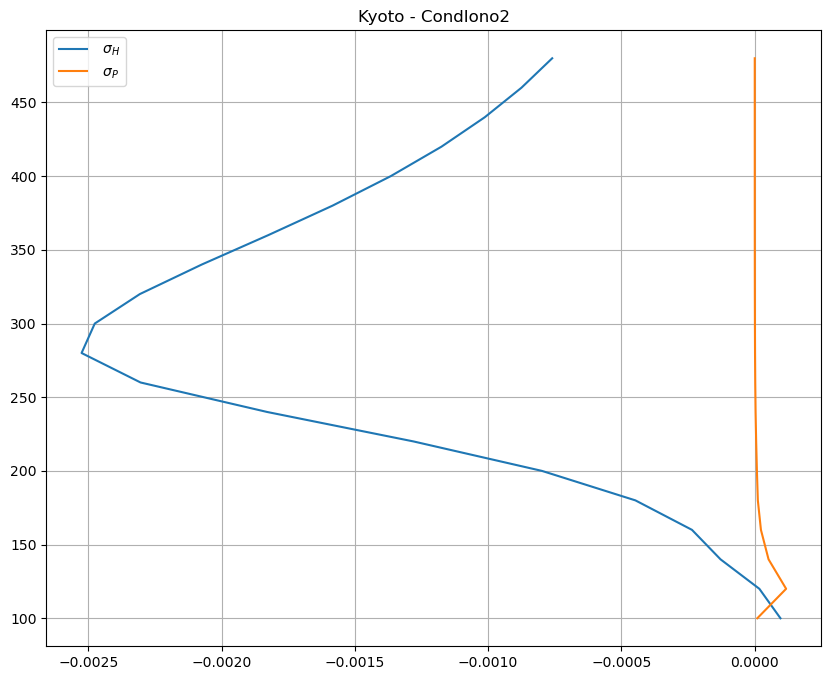

In [19]:
#plt.semilogx(diff_hall,diff_hall.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Hall")
#plt.plot(diff_pedersen,diff_pedersen.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Pedersen")
plt.figure(figsize = (10,8))
plt.plot(condkyoto2["S2"].loc[:h] - plothall['0'].loc[:h],condkyoto2.loc[:h].index.get_level_values('HEIGHT').unique(),label = " $\sigma_H$")
plt.plot(condkyoto2["S1"].loc[:h] - plotpedersen['0'].loc[:h],pedersen.loc["0 days 00:00:00",:h,:,:].index.get_level_values('ht').unique(), label = " $\sigma_P$")

plt.legend()
plt.title("Kyoto - CondIono2")
plt.grid()
plt.savefig("kyoto-CondutividadePedersen_lat-60_lon120_s20_01JAN2008.jpg",dpi=300)

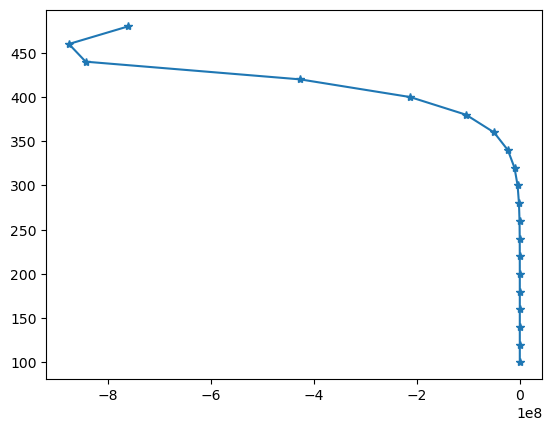

In [20]:
plt.plot(diff_hall/condkyoto2["S2"],height,'*-')

In [21]:
diff_hall/condkyoto2["S2"]

HEIGHT
100.0   -4.190976e-01
120.0    2.241886e-01
140.0   -9.847721e+00
160.0   -1.672130e+02
180.0   -1.577964e+03
200.0   -7.866495e+03
220.0   -3.497749e+04
240.0   -1.490942e+05
260.0   -5.427663e+05
280.0   -1.637832e+06
300.0   -4.256970e+06
320.0   -1.027329e+07
340.0   -2.316075e+07
360.0   -4.997427e+07
380.0   -1.043823e+08
400.0   -2.128614e+08
420.0   -4.264093e+08
440.0   -8.426123e+08
460.0   -8.751999e+08
480.0   -7.597386e+08
dtype: float64

In [22]:
# #plt.plot(plothall['0']/condkyoto2["S2"],diff_hall.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Hall")
# plt.plot(plotpedersen['0']/condkyoto2["S1"],diff_hall.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono pedersen")
# plt.legend()

In [23]:
plotpedersen

,0
ht,
100.0,9.570178e-08
120.0,1.284850e-08
140.0,6.849647e-09
160.0,5.422219e-09
180.0,5.105289e-09
200.0,4.650866e-09
220.0,3.623914e-09
240.0,2.400944e-09
260.0,1.419036e-09


In [24]:
import numpy as np
import scipy.integrate as scp

In [25]:
def calc_height_integrtated_conductivity(values):
    #list to be filled with height intratade values. cada linha é numa latitude específica e coluna uma longitude
    print(values, type(values))
    print(values.index.get_level_values('ht').unique())    
    heightintegratedcond = scp.trapz(values,values.index.get_level_values('ht').unique())

    return heightintegratedcond 

In [26]:
plothall.loc[:480]['0'],scp.trapz(plotpedersen.loc[:480]["0"],plothall.loc[:480].index.get_level_values('ht').unique()*1000) #multiplica por 1000 pq altura está em km

(ht
 100.0    0.000086
 120.0    0.000093
 140.0    0.000137
 160.0    0.000237
 180.0    0.000448
 200.0    0.000798
 220.0    0.001280
 240.0    0.001829
 260.0    0.002304
 280.0    0.002525
 300.0    0.002476
 320.0    0.002306
 340.0    0.002075
 360.0    0.001825
 380.0    0.001584
 400.0    0.001366
 420.0    0.001175
 440.0    0.001013
 460.0    0.000875
 480.0    0.000760
 Name: 0, dtype: float64,
 0.0018306410739071534)

In [27]:
import scipy.integrate as scp


In [28]:
scp.trapz(condkyoto2['S1'],condkyoto2['S2'].index.get_level_values("HEIGHT")*1000)

4.599696295399999

In [29]:
np.trapz(condkyoto2['S2'],condkyoto2['S2'].index.get_level_values("HEIGHT"))

0.0042390026087274005